# Setup

In [1]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, DataCollatorWithPadding, BertModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import torch.nn as nn
from torch.utils.data import DataLoader
from datasets import Dataset, DatasetDict
import random
from gensim.models import Doc2Vec
from gensim.models.phrases import Phrases, Phraser
from gensim.models.doc2vec import TaggedDocument
from utils.functions import group_texts, sentiment_code, topic_code,party_deu, clean_text_loop, sentiment_code_coalition, topic_code_coalition
from utils.functions import train_loop, eval_loop, tokenize_function, d2v_reduct, scale_func, recode_tw, copy_weights
# Import the new uncertainty module
from utils.uncertainty import (
    ensemble_inference,
    train_deep_ensemble,
    load_ensemble_models,
    save_ensemble_results,
    create_ensemble_summary_dataframe
)
from utils.models import ContextScalePrediction, corpusIterator, phraseIterator
from safetensors.torch import load_file, save_file
from sklearn.decomposition import PCA
import pickle
import nltk
#nltk.download('stopwords') ## Remove comments and do it once if you haven't

In [2]:
torch.cuda.empty_cache() 
device = torch.device('cuda')
torch.cuda.get_device_name(device=None)


'NVIDIA RTX PRO 6000 Blackwell Workstation Edition'

In [3]:
## Pseudo-randomness for reproducibility
seed_val = 1234
torch.manual_seed(seed_val)
random.seed(seed_val)
np.random.seed(seed_val)


# Small test of BERT embeddings

In [ ]:
model_name = 'bert-base-cased'

In [ ]:
model = BertModel.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
sentence_a = 'I went to the river bank'
sentence_b = 'I went to the bank by the river'
tok_a = tokenizer(sentence_a, return_tensors='pt')
tok_b = tokenizer(sentence_b, return_tensors='pt')

In [ ]:
tok_a

In [ ]:
tok_b

In [ ]:
with torch.no_grad():
    outputs_a = model(**tok_a)
    outputs_b = model(**tok_b)
# Extract word embeddings from the last hidden layer
last_hidden_states_a = outputs_a.last_hidden_state
last_hidden_states_b = outputs_b.last_hidden_state

# Extract the word embedding for the first token (CLS token)
word_embedding_a = last_hidden_states_a[:, -2, :] ## 0 is the CLS token, river is the last token
word_embedding_b = last_hidden_states_b[:, 5, :]

In [ ]:
np.corrcoef(word_embedding_a.numpy(), word_embedding_b.numpy()).round(2)

# Implementation

## Data preparation

In [ ]:
manifesto = pd.read_csv(os.path.join("data", "r_outputs","pulled_manifestoes.csv"), encoding="utf-8", dtype = {2: 'str', 18:'str'})

In [ ]:
manifesto.info()

In [ ]:
manifesto = manifesto[(manifesto.cmp_code.notna()) & ~(manifesto.cmp_code.isin(['H']))].reset_index(drop=True)
len(manifesto)

In [ ]:
manifesto['sentiment'] = manifesto['cmp_code'].apply(sentiment_code)
manifesto['topic'] = manifesto['cmp_code'].apply(topic_code)
manifesto['election'] = manifesto['date'].astype(str).str[:4]

In [ ]:
manifesto.groupby(['topic','sentiment']).count()

In [ ]:
grouped_result = manifesto.groupby(['topic', 'sentiment', 'cmp_code']).size().reset_index(name='count')
grouped_result


In [ ]:
manifesto.groupby('sentiment').count()

In [ ]:
len(manifesto[manifesto.topic=="Military"])/len(manifesto)*100 ## minority group: 1.7%

In [ ]:
texts = manifesto['text'].tolist()

In [ ]:
from statistics import stdev, mean
## Before
seq_len = [len(i.split()) for i in texts]
seq_len_mean = mean(seq_len)
seq_len_std = stdev(seq_len)
seq_len_max = max(seq_len)
seq_len_min = min(seq_len)
print('Mean length (word) is: {}'.format(seq_len_mean))
print('Std length (word) is: {}'.format(seq_len_std))
print('Min length (word) is: {}'.format(seq_len_min))
print('Max length (word) is: {}'.format(seq_len_max))

In [ ]:
pd.Series(seq_len).hist(bins = 30)

In [ ]:
results = group_texts(manifesto, 
                      ['countryname','election','party','cmp_code'], 'text', 
                      max_group_factor = 5)

In [ ]:
manifesto_regrouped = pd.DataFrame(results)
manifesto_regrouped = manifesto_regrouped.explode('text').reset_index(drop=True)

In [ ]:
df_cols = manifesto_regrouped['labels'].str.split(';', expand=True)
manifesto_regrouped = pd.concat([manifesto_regrouped, df_cols], axis=1)


In [ ]:
manifesto_regrouped.columns = ['text', 'idx', 'country','election', 'party', 'cmp_code']

In [ ]:
manifesto_regrouped.head()

In [ ]:
manifesto_regrouped.loc[:,'sentiment'] = manifesto_regrouped['cmp_code'].apply(sentiment_code)
manifesto_regrouped.loc[:,'topic'] = manifesto_regrouped['cmp_code'].apply(topic_code)
manifesto_regrouped = manifesto_regrouped.drop_duplicates().reset_index(drop=True)


In [ ]:
manifesto_regrouped.groupby(['topic','sentiment']).count()

In [ ]:
texts = manifesto_regrouped['text'].tolist()
from statistics import stdev, mean
## Before
seq_len = [len(i.split()) for i in texts]
seq_len_mean = mean(seq_len)
seq_len_std = stdev(seq_len)
seq_len_max = max(seq_len)
seq_len_min = min(seq_len)
print('Mean length (word) is: {}'.format(seq_len_mean))
print('Std length (word) is: {}'.format(seq_len_std))
print('Min length (word) is: {}'.format(seq_len_min))
print('Max length (word) is: {}'.format(seq_len_max))

In [ ]:
pd.Series(seq_len).hist(bins = 30)

In [ ]:
manifesto_regrouped.to_csv('data/py_outputs/manifesto_regrouped.csv', encoding='utf-8', index=False)
manifesto.to_csv('data/py_outputs/manifesto.csv', encoding='utf-8', index=False)

## Preparing dataloaders 

In [ ]:
manifesto = pd.read_csv('data/py_outputs/manifesto.csv', encoding='utf-8', dtype={2:'str',18: 'str'})
manifesto_regrouped = pd.read_csv('data/py_outputs/manifesto_regrouped.csv', encoding='utf-8')

In [ ]:
manifesto_reduced = manifesto_regrouped[['topic','sentiment','text']].reset_index(drop=True)

In [ ]:
model_name = 'xlm-roberta-base' 
tokenizer = AutoTokenizer.from_pretrained(model_name)
data_collator = DataCollatorWithPadding(tokenizer)

In [ ]:
manifesto_reduced['topic_sentiment'] = manifesto_reduced['topic'] + '_' + manifesto_reduced['sentiment']

In [ ]:
manifesto_dataset = Dataset.from_pandas(manifesto_reduced)
manifesto_dataset = manifesto_dataset.class_encode_column('topic')
manifesto_dataset = manifesto_dataset.class_encode_column('sentiment')
manifesto_dataset = manifesto_dataset.class_encode_column('topic_sentiment')



In [ ]:
## Save class labels
import pickle
topic_labels = manifesto_dataset.features['topic'].names
file_path = 'data/py_outputs/topic_labels'
with open(file_path, 'wb') as fp:
    pickle.dump(topic_labels, fp)

sentiment_labels = manifesto_dataset.features['sentiment'].names
file_path = 'data/py_outputs/sentiment_labels'
with open(file_path, 'wb') as fp:
    pickle.dump(sentiment_labels, fp)

In [ ]:
train_test = manifesto_dataset.train_test_split(test_size=0.1, stratify_by_column='topic_sentiment', seed=seed_val)
train_eval = train_test['train'].train_test_split(test_size=0.3, stratify_by_column='topic_sentiment', seed=seed_val )

In [ ]:
manifesto_datasets = DatasetDict({
    'train': train_eval['train'],
    'test': train_test['test'],
    'eval': train_eval['test']
})
manifesto_datasets

In [ ]:
tokenized_datasets = manifesto_datasets.map(tokenize_function, 
                                            fn_kwargs={'tokenizer': tokenizer, 'text_var': 'text', 'max_length': 512}, 
                                            remove_columns=['text', 'topic_sentiment'])
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

In [ ]:
train_dataloader = DataLoader(tokenized_datasets['train'], batch_size=64, shuffle=True, collate_fn = data_collator)
test_dataloader = DataLoader(tokenized_datasets['test'], batch_size=64, shuffle=False, collate_fn = data_collator)
eval_dataloader = DataLoader(tokenized_datasets['eval'], batch_size=64, shuffle=False, collate_fn = data_collator)

## Deep Ensemble Inference


### Configuration 

In [ ]:
# Define model factory function for ensemble training
num_topics = len(set(manifesto_dataset['topic']))
num_sentiments = len(set(manifesto_dataset['sentiment']))
model_base = ContextScalePrediction(
        roberta_model=model_name, 
        num_topics=num_topics, 
        num_sentiments=num_sentiments,
        lora=False,
        use_shared_attention=True  # Using shared attention architecture
    )

print("Model defined")

### Ensemble inference on the test set

Training is done using train.py script. Here we implement ensemble inference on test set.

In [ ]:
# Generate checkpoint paths for the ensemble models trained with different splits
checkpoint_paths_splits = [
    os.path.join('results/models/ensemble', f"model_ensemble_{i}.safetensors")
    for i in range(5)
]

print("Checkpoint paths for split-based ensemble:")
for i, path in enumerate(checkpoint_paths_splits):
    print(f"  Model {i}: {path}")

# Load the ensemble models
ensemble_models = load_ensemble_models(
    model_base=model_base,
    checkpoint_paths=checkpoint_paths_splits,
    device=device
)

In [ ]:
# Perform ensemble inference with uncertainty estimation
print("Performing ensemble inference with uncertainty estimation...")
print("The ensemble will compute:")
print("  - Mean position scores across all 5 models")
print("  - Position score variance for each text sequence")
print("  - Epistemic uncertainty (model disagreement)")
print("  - Aleatoric uncertainty (inherent data uncertainty)")

ensemble_results = ensemble_inference(
    models=ensemble_models,
    dataloader=test_dataloader,
    device=device,
    beta=1.0,
    topic_label='topic',
    sentiment_label='sentiment',
    use_ground_truth_topic=True
)

print(f"\nEnsemble inference completed!")
print(f"Final position scores are the mean of {len(ensemble_models)} models")
print(f"Position score variance included for each sequence")

save_ensemble_results(
    ensemble_results,
    'results/datasets/ensemble_results_test.pkl'
)

### Merge back to original test dataset

In [ ]:
## Load ensemble results with pickle
file_path = 'results/datasets/ensemble_results_test.pkl'
with open(file_path, "rb") as file:
    ensemble_results = pickle.load(file)

In [ ]:
ensemble_summary_df = create_ensemble_summary_dataframe(ensemble_results)

In [ ]:
## Merge ensemble_summary_df with original test dataset for analysis
test_dataset = manifesto_datasets['test'].to_pandas().reset_index(drop=True)
merged_df = pd.concat([test_dataset, ensemble_summary_df], axis=1)

In [ ]:
## Save to csv
merged_df.to_csv('results/datasets/ensemble_test_dataset.csv', index=False)

In [ ]:
precision_sentiment, recall_sentiment, f1_sentiment, _ = precision_recall_fscore_support(merged_df['ground_truth_sentiment'], 
                                                                                         merged_df['ensemble_pred_sentiment'], average=None)
matrix_sentiment = confusion_matrix(merged_df['ground_truth_sentiment'], merged_df['ensemble_pred_sentiment'])
accuracy_sentiment = matrix_sentiment.diagonal() / matrix_sentiment.sum(axis=1)

# Prepare result table for sentiments
res_table_sentiment = pd.DataFrame({
    'f1': np.round(f1_sentiment, 2),
    'precision': np.round(precision_sentiment, 2),
    'recall': np.round(recall_sentiment, 2),
    'accuracy': np.round(accuracy_sentiment, 2)
})
precision_topic, recall_topic, f1_topic, _ = precision_recall_fscore_support(merged_df['ground_truth_topic'], 
                                                                             merged_df['ensemble_pred_topic'], average=None)
matrix_topic = confusion_matrix(merged_df['ground_truth_topic'], merged_df['ensemble_pred_topic'])
accuracy_topic = matrix_topic.diagonal() / matrix_topic.sum(axis=1)

# Prepare result table for topics
res_table_topic = pd.DataFrame({
    'f1': np.round(f1_topic, 2),
    'precision': np.round(precision_topic, 2),
    'recall': np.round(recall_topic, 2),
    'accuracy': np.round(accuracy_topic, 2)
})

In [ ]:
res_table_sentiment.to_csv('results/classification results/test_sentiment.csv')
res_table_topic.to_csv('results/classification results/test_topic.csv')

### Inference on the entire dataset 


In [ ]:
# Generate checkpoint paths for the ensemble models trained with different splits
checkpoint_paths_splits = [
    os.path.join('results/models/ensemble_scaling', f"model_ensemble_{i}.safetensors")
    for i in range(5)
]

print("Checkpoint paths for split-based ensemble:")
for i, path in enumerate(checkpoint_paths_splits):
    print(f"  Model {i}: {path}")

# Load the ensemble models
ensemble_models = load_ensemble_models(
    model_base=model_base,
    checkpoint_paths=checkpoint_paths_splits,
    device=device
)

In [ ]:
full_dataset = manifesto_dataset.map(tokenize_function, 
                                            fn_kwargs={'tokenizer': tokenizer, 'text_var': 'text', 'max_length': 512}, 
                                            remove_columns=['text'])
full_dataset.set_format("torch")
full_dataloader = DataLoader(full_dataset, batch_size=64, shuffle=False, collate_fn=data_collator)

full_ensemble_results = ensemble_inference(
    models=ensemble_models,
    dataloader=full_dataloader,
    device=device,
    beta=1.0,
    topic_label='topic',
    sentiment_label='sentiment',
    use_ground_truth_topic=True
)

save_ensemble_results(
    full_ensemble_results,
    'results/datasets/ensemble_results_full.pkl'
)



In [ ]:
## Load ensemble results with pickle
file_path = 'results/datasets/ensemble_results_full.pkl'
with open(file_path, "rb") as file:
    full_ensemble_results = pickle.load(file)

In [ ]:
ensemble_summary_df = create_ensemble_summary_dataframe(full_ensemble_results)

In [ ]:
## Merge ensemble_summary_df with original test dataset for analysis
merged_df = pd.concat([manifesto_regrouped, ensemble_summary_df], axis=1)

In [ ]:
## Save to csv
merged_df.to_csv('results/datasets/ensemble_full_dataset.csv', index=False)

# Validity checks

### Different languages

#### Testing on test languages unseen during training

In [ ]:
manifesto_test = pd.read_csv(os.path.join("data", "r_outputs","pulled_manifestoes_test.csv"), encoding="utf-8")

In [ ]:
manifesto_test.info()

In [ ]:
manifesto_test = manifesto_test[(manifesto_test.cmp_code.notna()) & ~(manifesto_test.cmp_code == 'H')].reset_index(drop=True)

In [ ]:
manifesto_test['sentiment'] = manifesto_test['cmp_code'].apply(sentiment_code)
manifesto_test['topic'] = manifesto_test['cmp_code'].apply(topic_code)
manifesto_test['election'] = manifesto_test['date'].astype(str).str[:4]

In [ ]:
results = group_texts(manifesto_test, 
                      ['countryname','election','party','cmp_code'], 'text', 
                      max_group_factor = 5)

In [ ]:
manifesto_regrouped = pd.DataFrame(results)
manifesto_regrouped = manifesto_regrouped.explode('text').reset_index(drop=True)

In [ ]:
df_cols = manifesto_regrouped['labels'].str.split(';', expand=True)
manifesto_regrouped = pd.concat([manifesto_regrouped, df_cols], axis=1)


In [ ]:
manifesto_regrouped.columns = ['text', 'country_election_party_code', 'country','election', 'party', 'cmp_code']

In [ ]:
manifesto_regrouped.head()

In [ ]:
manifesto_regrouped.loc[:,'sentiment'] = manifesto_regrouped['cmp_code'].apply(sentiment_code)
manifesto_regrouped.loc[:,'topic'] = manifesto_regrouped['cmp_code'].apply(topic_code)
manifesto_regrouped = manifesto_regrouped.drop_duplicates().reset_index(drop=True)


In [ ]:
manifesto_regrouped.groupby(['topic','sentiment']).count()

In [ ]:
manifesto_reduced = manifesto_regrouped[['topic','sentiment','text']].reset_index(drop=True)

In [ ]:
model_name = 'xlm-roberta-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)
data_collator = DataCollatorWithPadding(tokenizer)

In [ ]:
manifesto_dataset = Dataset.from_pandas(manifesto_reduced)
manifesto_dataset = manifesto_dataset.class_encode_column('topic')
manifesto_dataset = manifesto_dataset.class_encode_column('sentiment')



In [ ]:
tokenized_dataset = manifesto_dataset.map(tokenize_function, 
                                            fn_kwargs={'tokenizer': tokenizer, 'text_var': 'text', 'max_length': 512}, 
                                            remove_columns=['text'])

In [ ]:
pred_dataloader = DataLoader(tokenized_dataset, batch_size=64, shuffle=False, collate_fn = data_collator)

In [ ]:
## Load ensemble models for validity checks
num_topics = len(set(manifesto_reduced['topic']))
num_sentiments = len(set(manifesto_reduced['sentiment']))

model_base = ContextScalePrediction(
        roberta_model=model_name,
        num_topics=num_topics,
        num_sentiments=num_sentiments,
        lora=False,
        use_shared_attention=True
    )

ensemble_checkpoint_paths = [
    os.path.join('results/models/ensemble_scaling', f"model_ensemble_{i}.safetensors")
    for i in range(5)
]

validity_ensemble_models = load_ensemble_models(
    model_base=model_base,
    checkpoint_paths=ensemble_checkpoint_paths,
    device=device
)

In [ ]:
outputs_dl = ensemble_inference(
    models=validity_ensemble_models,
    dataloader=pred_dataloader,
    device=device,
    beta=1.0,
    topic_label='topic',
    sentiment_label='sentiment',
    use_ground_truth_topic=False
)

true_topics = outputs_dl.get('ground_truth_topics')
if true_topics is not None:
    true_topics = np.asarray(true_topics).ravel()
    topic_precision, topic_recall, topic_f1, _ = precision_recall_fscore_support(
        true_topics,
        outputs_dl['ensemble_pred_topics'],
        average=None
    )
    matrix_topic = confusion_matrix(true_topics, outputs_dl['ensemble_pred_topics'])
    accuracy_topic = matrix_topic.diagonal() / matrix_topic.sum(axis=1)
    outputs_dl['res_table_topic'] = pd.DataFrame({
        'f1': np.round(topic_f1, 2),
        'precision': np.round(topic_precision, 2),
        'recall': np.round(topic_recall, 2),
        'accuracy': np.round(accuracy_topic, 2)
    })
else:
    outputs_dl['res_table_topic'] = None

true_sentiments = outputs_dl.get('ground_truth_sentiments')
if true_sentiments is not None:
    true_sentiments = np.asarray(true_sentiments).ravel()
    sent_precision, sent_recall, sent_f1, _ = precision_recall_fscore_support(
        true_sentiments,
        outputs_dl['ensemble_pred_sentiments'],
        average=None
    )
    matrix_sentiment = confusion_matrix(true_sentiments, outputs_dl['ensemble_pred_sentiments'])
    accuracy_sentiment = matrix_sentiment.diagonal() / matrix_sentiment.sum(axis=1)
    outputs_dl['res_table_sentiment'] = pd.DataFrame({
        'f1': np.round(sent_f1, 2),
        'precision': np.round(sent_precision, 2),
        'recall': np.round(sent_recall, 2),
        'accuracy': np.round(accuracy_sentiment, 2)
    })
else:
    outputs_dl['res_table_sentiment'] = None

In [ ]:
outputs_dl['res_table_topic'].mean().round(2)

In [ ]:
outputs_dl['res_table_sentiment'].mean().round(2)

In [ ]:
outputs_dl['res_table_sentiment'].to_csv('results/classification results/dl_sentiment.csv', index=False)
outputs_dl['res_table_topic'].to_csv('results/classification results/dl_topic.csv', index=False)


#### Train a model using only 10% of labelled data

In [ ]:
manifesto_reduced['topic_sentiment'] = manifesto_reduced['topic'] + '_' + manifesto_reduced['sentiment']

In [ ]:
manifesto_dataset = Dataset.from_pandas(manifesto_reduced)
manifesto_dataset = manifesto_dataset.class_encode_column('topic')
manifesto_dataset = manifesto_dataset.class_encode_column('sentiment')
manifesto_dataset = manifesto_dataset.class_encode_column('topic_sentiment')



In [ ]:
train_test = manifesto_dataset.train_test_split(test_size=0.9, stratify_by_column='topic_sentiment', seed=seed_val)

In [ ]:
manifesto_datasets = DatasetDict({
    'train': train_test['train'],
    'test': train_test['test'],
})
manifesto_datasets

In [ ]:
tokenized_datasets = manifesto_datasets.map(tokenize_function, 
                                            fn_kwargs={'tokenizer': tokenizer, 'text_var': 'text', 'max_length': 512}, 
                                            remove_columns=['text', 'topic_sentiment'])
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

In [ ]:
train_dataloader = DataLoader(tokenized_datasets['train'], batch_size=64, shuffle=True, collate_fn = data_collator)
test_dataloader = DataLoader(tokenized_datasets['test'], batch_size=64, shuffle=False, collate_fn = data_collator)

In [ ]:
## Define ensemble model factories for 10% labelled subset with borrowed weights
num_topics = len(set(manifesto_reduced['topic']))
num_sentiments = len(set(manifesto_reduced['sentiment']))

checkpoint_path = os.path.join('results/models/ensemble_scaling/model_ensemble_1.safetensors')

print("Manifesto ensemble members used for 10% supervision adaptation:")



def copy_source_model(checkpoint_path):
    source_model = ContextScalePrediction(
        roberta_model=model_name,
        num_topics=num_topics,
        num_sentiments=num_sentiments,
        lora=False,
        use_shared_attention=True
    ).to(device)
    source_state = load_file(checkpoint_path)
    source_model.load_state_dict(source_state)

    return source_model


model_base = copy_source_model(checkpoint_path=checkpoint_path)

In [ ]:

ensemble_training_info_dl_10 = train_deep_ensemble(
    model_base=model_base,
    train_dataloader=train_dataloader,
    eval_dataloader=None,
    device=device,
    num_models=5,
    n_epochs=5,
    lr=2e-5,
    sentiment_var='sentiment',
    topic_var='topic',
    save_dir='results/models/manifesto_ensemble_dl_10',
    model_prefix='model_ensemble_dl_10',
    org_seed=seed_val
)

In [ ]:
checkpoint_paths_dl_10 = [
    os.path.join('results/models/manifesto_ensemble_dl_10', f"model_ensemble_dl_10_{i}.safetensors")
    for i in range(5)
]

print("Checkpoint paths for 10% ensemble:")
for idx, path in enumerate(checkpoint_paths_dl_10):
    print(f"  Model {idx}: {path}")

manifesto_ensemble_dl_10_models = load_ensemble_models(
    model_base=model_base,
    checkpoint_paths=checkpoint_paths_dl_10,
    device=device
)

In [ ]:
outputs_dl_10 = ensemble_inference(
    models=manifesto_ensemble_dl_10_models,
    dataloader=test_dataloader,
    device=device,
    beta=1.0,
    topic_label='topic',
    sentiment_label='sentiment',
    use_ground_truth_topic=False
)

true_topics_dl_10 = outputs_dl_10.get('ground_truth_topics')
if true_topics_dl_10 is not None:
    true_topics_dl_10 = np.asarray(true_topics_dl_10).ravel()
    topic_precision_dl_10, topic_recall_dl_10, topic_f1_dl_10, _ = precision_recall_fscore_support(
        true_topics_dl_10,
        outputs_dl_10['ensemble_pred_topics'],
        average=None
    )
    matrix_topic_dl_10 = confusion_matrix(true_topics_dl_10, outputs_dl_10['ensemble_pred_topics'])
    accuracy_topic_dl_10 = matrix_topic_dl_10.diagonal() / matrix_topic_dl_10.sum(axis=1)
    outputs_dl_10['res_table_topic'] = pd.DataFrame({
        'f1': np.round(topic_f1_dl_10, 2),
        'precision': np.round(topic_precision_dl_10, 2),
        'recall': np.round(topic_recall_dl_10, 2),
        'accuracy': np.round(accuracy_topic_dl_10, 2)
    })
else:
    outputs_dl_10['res_table_topic'] = None

true_sentiments_dl_10 = outputs_dl_10.get('ground_truth_sentiments')
if true_sentiments_dl_10 is not None:
    true_sentiments_dl_10 = np.asarray(true_sentiments_dl_10).ravel()
    sent_precision_dl_10, sent_recall_dl_10, sent_f1_dl_10, _ = precision_recall_fscore_support(
        true_sentiments_dl_10,
        outputs_dl_10['ensemble_pred_sentiments'],
        average=None
    )
    matrix_sentiment_dl_10 = confusion_matrix(true_sentiments_dl_10, outputs_dl_10['ensemble_pred_sentiments'])
    accuracy_sentiment_dl_10 = matrix_sentiment_dl_10.diagonal() / matrix_sentiment_dl_10.sum(axis=1)
    outputs_dl_10['res_table_sentiment'] = pd.DataFrame({
        'f1': np.round(sent_f1_dl_10, 2),
        'precision': np.round(sent_precision_dl_10, 2),
        'recall': np.round(sent_recall_dl_10, 2),
        'accuracy': np.round(accuracy_sentiment_dl_10, 2)
    })
else:
    outputs_dl_10['res_table_sentiment'] = None

outputs_dl_10['position_scores'] = outputs_dl_10['mean_position_scores']
outputs_dl_10['pred_topics'] = outputs_dl_10['ensemble_pred_topics']
outputs_dl_10['pred_sentiment'] = outputs_dl_10['ensemble_pred_sentiments']

In [ ]:
outputs_dl_10['res_table_topic']['f1'].mean().round(2)

In [ ]:
outputs_dl_10['res_table_sentiment']['f1'].mean().round(2)

In [ ]:
outputs_dl_10['res_table_sentiment'].to_csv('results/classification results/dl_10_sentiment.csv', index=False)
outputs_dl_10['res_table_topic'].to_csv('results/classification results/dl_10_topic.csv', index=False)


### COALITIONAGREE, same coding style

#### No supervision

In [ ]:
coalitionagree = pd.read_csv('data/r_outputs/coalitionagree_texts.csv', encoding='utf-8', index_col=0).reset_index(drop=True)

In [ ]:
coalitionagree.head()

In [ ]:
results = group_texts(coalitionagree, ['country','cabinet_year','category2','category3'], 'sentence', max_group_factor = 5)

In [ ]:
coalition_regrouped = pd.DataFrame(results)
coalition_regrouped = coalition_regrouped.explode('text').reset_index(drop=True)
df_cols = coalition_regrouped['labels'].str.split(';', expand=True)
coalition_regrouped = pd.concat([coalition_regrouped, df_cols], axis=1)
coalition_regrouped.columns =['text','labels', 'country','year', 'cmp_short','cmp_long']


In [ ]:
coalition_regrouped.head()

In [ ]:
coalition_regrouped['sentiment'] = coalition_regrouped.apply(lambda x: sentiment_code_coalition(x['cmp_short'], x['cmp_long']), axis=1)
coalition_regrouped['topic'] = coalition_regrouped['cmp_short'].apply(topic_code_coalition)

In [ ]:
coalition_regrouped.groupby(['topic','sentiment']).count()

In [ ]:
cagree_reduced = coalition_regrouped[['sentiment', 'topic','text']].copy()

In [ ]:
cagree_dataset = Dataset.from_pandas(cagree_reduced)
cagree_dataset = cagree_dataset.class_encode_column('sentiment')
cagree_dataset = cagree_dataset.class_encode_column('topic')


In [ ]:
tokenized_dataset = cagree_dataset.map(tokenize_function, 
                                            fn_kwargs={'tokenizer': tokenizer, 'text_var': 'text', 'max_length': 512}, 
                                            remove_columns=['text'])

In [ ]:
pred_dataloader = DataLoader(tokenized_dataset, batch_size=64, shuffle=False, collate_fn = data_collator)

In [ ]:
## Load ensemble models for validity checks
num_topics = len(set(cagree_reduced['topic']))
num_sentiments = len(set(cagree_reduced['sentiment']))

model_base = ContextScalePrediction(
        roberta_model=model_name,
        num_topics=num_topics,
        num_sentiments=num_sentiments,
        lora=False,
        use_shared_attention=True
    )

ensemble_checkpoint_paths = [
    os.path.join('results/models/ensemble_scaling', f"model_ensemble_{i}.safetensors")
    for i in range(5)
]

validity_ensemble_models = load_ensemble_models(
    model_base=model_base,
    checkpoint_paths=ensemble_checkpoint_paths,
    device=device
)

In [ ]:
outputs_ca_test = ensemble_inference(
    models=validity_ensemble_models,
    dataloader=pred_dataloader,
    device=device,
    beta=1.0,
    topic_label='topic',
    sentiment_label='sentiment',
    use_ground_truth_topic=False
)

true_topics_ca = outputs_ca_test.get('ground_truth_topics')
if true_topics_ca is not None:
    true_topics_ca = np.asarray(true_topics_ca).ravel()
    topic_precision_ca, topic_recall_ca, topic_f1_ca, _ = precision_recall_fscore_support(
        true_topics_ca,
        outputs_ca_test['ensemble_pred_topics'],
        average=None
    )
    matrix_topic_ca = confusion_matrix(true_topics_ca, outputs_ca_test['ensemble_pred_topics'])
    accuracy_topic_ca = matrix_topic_ca.diagonal() / matrix_topic_ca.sum(axis=1)
    outputs_ca_test['res_table_topic'] = pd.DataFrame({
        'f1': np.round(topic_f1_ca, 2),
        'precision': np.round(topic_precision_ca, 2),
        'recall': np.round(topic_recall_ca, 2),
        'accuracy': np.round(accuracy_topic_ca, 2)
    })
else:
    outputs_ca_test['res_table_topic'] = None

true_sentiments_ca = outputs_ca_test.get('ground_truth_sentiments')
if true_sentiments_ca is not None:
    true_sentiments_ca = np.asarray(true_sentiments_ca).ravel()
    sent_precision_ca, sent_recall_ca, sent_f1_ca, _ = precision_recall_fscore_support(
        true_sentiments_ca,
        outputs_ca_test['ensemble_pred_sentiments'],
        average=None
    )
    matrix_sentiment_ca = confusion_matrix(true_sentiments_ca, outputs_ca_test['ensemble_pred_sentiments'])
    accuracy_sentiment_ca = matrix_sentiment_ca.diagonal() / matrix_sentiment_ca.sum(axis=1)
    outputs_ca_test['res_table_sentiment'] = pd.DataFrame({
        'f1': np.round(sent_f1_ca, 2),
        'precision': np.round(sent_precision_ca, 2),
        'recall': np.round(sent_recall_ca, 2),
        'accuracy': np.round(accuracy_sentiment_ca, 2)
    })
else:
    outputs_ca_test['res_table_sentiment'] = None

outputs_ca_test['position_scores'] = outputs_ca_test['mean_position_scores']
outputs_ca_test['pred_topics'] = outputs_ca_test['ensemble_pred_topics']
outputs_ca_test['pred_sentiment'] = outputs_ca_test['ensemble_pred_sentiments']

In [ ]:
outputs_ca_test['res_table_sentiment']['f1'].mean().round(2)

In [ ]:
outputs_ca_test['res_table_topic']['f1'].mean().round(2)

In [ ]:
outputs_ca_test['res_table_sentiment'].to_csv('results/classification results/cagree_noft_sentiment.csv', index=False)
outputs_ca_test['res_table_topic'].to_csv('results/classification results/cagree_noft_topic.csv', index=False)


#### 10% supervision

In [ ]:
cagree_reduced.loc[:,'topic_sentiment'] = cagree_reduced.loc[:,'topic'] + '_' + cagree_reduced.loc[:,'sentiment']

In [ ]:
cagree_dataset = Dataset.from_pandas(cagree_reduced)
cagree_dataset = cagree_dataset.class_encode_column('sentiment')
cagree_dataset = cagree_dataset.class_encode_column('topic')
cagree_dataset = cagree_dataset.class_encode_column('topic_sentiment')

In [ ]:
train_test = cagree_dataset.train_test_split(test_size=0.9, stratify_by_column='topic_sentiment', seed=seed_val)

In [ ]:
cagree_datasets = DatasetDict({
    'train': train_test['train'],
    'test': train_test['test'],
})
cagree_datasets

In [ ]:
tokenized_datasets = cagree_datasets.map(tokenize_function, 
                                            fn_kwargs={'tokenizer': tokenizer, 'text_var': 'text', 'max_length': 512}, 
                                            remove_columns=['text','topic_sentiment'])
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

In [ ]:
train_dataloader = DataLoader(tokenized_datasets['train'], batch_size=64, shuffle=True, collate_fn = data_collator)
test_dataloader = DataLoader(tokenized_datasets['test'], batch_size=64, shuffle=False, collate_fn = data_collator)


In [ ]:
## Define ensemble model factories for 10% labelled subset with borrowed weights
num_topics = len(set(cagree_reduced['topic']))
num_sentiments = len(set(cagree_reduced['sentiment']))

checkpoint_path = os.path.join('results/models/ensemble_scaling/model_ensemble_1.safetensors')

print("Manifesto ensemble members used for 10% supervision adaptation:")



def copy_source_model(checkpoint_path):
    source_model = ContextScalePrediction(
        roberta_model=model_name,
        num_topics=num_topics,
        num_sentiments=num_sentiments,
        lora=False,
        use_shared_attention=True
    ).to(device)
    source_state = load_file(checkpoint_path)
    source_model.load_state_dict(source_state)

    return source_model


model_base = copy_source_model(checkpoint_path=checkpoint_path)

In [ ]:
ensemble_training_info_ca_10 = train_deep_ensemble(
    model_base=model_base,
    train_dataloader=train_dataloader,
    eval_dataloader=None,
    device=device,
    num_models=5,
    n_epochs=5,
    lr=2e-5,
    sentiment_var='sentiment',
    topic_var='topic',
    save_dir='results/models/coalitionagree_ensemble_10',
    model_prefix='model_ensemble_ca_10',
    org_seed=seed_val
)

In [ ]:
coalition_ensemble_checkpoint_paths = [
    os.path.join('results/models/coalitionagree_ensemble_10', f"model_ensemble_ca_10_{i}.safetensors")
    for i in range(5)
]

print("Checkpoint paths for COALITIONAGREE 10% ensemble:")
for idx, path in enumerate(coalition_ensemble_checkpoint_paths):
    print(f"  Model {idx}: {path}")

coalitionagree_ensemble_10_models = load_ensemble_models(
    model_base=model_base,
    checkpoint_paths=coalition_ensemble_checkpoint_paths,
    device=device
)

In [ ]:
outputs_ca_10 = ensemble_inference(
    models=coalitionagree_ensemble_10_models,
    dataloader=test_dataloader,
    device=device,
    beta=1.0,
    topic_label='topic',
    sentiment_label='sentiment',
    use_ground_truth_topic=False
)

true_topics_ca_10 = outputs_ca_10.get('ground_truth_topics')
if true_topics_ca_10 is not None:
    true_topics_ca_10 = np.asarray(true_topics_ca_10).ravel()
    topic_precision_ca_10, topic_recall_ca_10, topic_f1_ca_10, _ = precision_recall_fscore_support(
        true_topics_ca_10,
        outputs_ca_10['ensemble_pred_topics'],
        average=None
    )
    matrix_topic_ca_10 = confusion_matrix(true_topics_ca_10, outputs_ca_10['ensemble_pred_topics'])
    accuracy_topic_ca_10 = matrix_topic_ca_10.diagonal() / matrix_topic_ca_10.sum(axis=1)
    outputs_ca_10['res_table_topic'] = pd.DataFrame({
        'f1': np.round(topic_f1_ca_10, 2),
        'precision': np.round(topic_precision_ca_10, 2),
        'recall': np.round(topic_recall_ca_10, 2),
        'accuracy': np.round(accuracy_topic_ca_10, 2)
    })
else:
    outputs_ca_10['res_table_topic'] = None

true_sentiments_ca_10 = outputs_ca_10.get('ground_truth_sentiments')
if true_sentiments_ca_10 is not None:
    true_sentiments_ca_10 = np.asarray(true_sentiments_ca_10).ravel()
    sent_precision_ca_10, sent_recall_ca_10, sent_f1_ca_10, _ = precision_recall_fscore_support(
        true_sentiments_ca_10,
        outputs_ca_10['ensemble_pred_sentiments'],
        average=None
    )
    matrix_sentiment_ca_10 = confusion_matrix(true_sentiments_ca_10, outputs_ca_10['ensemble_pred_sentiments'])
    accuracy_sentiment_ca_10 = matrix_sentiment_ca_10.diagonal() / matrix_sentiment_ca_10.sum(axis=1)
    outputs_ca_10['res_table_sentiment'] = pd.DataFrame({
        'f1': np.round(sent_f1_ca_10, 2),
        'precision': np.round(sent_precision_ca_10, 2),
        'recall': np.round(sent_recall_ca_10, 2),
        'accuracy': np.round(accuracy_sentiment_ca_10, 2)
    })
else:
    outputs_ca_10['res_table_sentiment'] = None

outputs_ca_10['position_scores'] = outputs_ca_10['mean_position_scores']
outputs_ca_10['pred_topics'] = outputs_ca_10['ensemble_pred_topics']
outputs_ca_10['pred_sentiment'] = outputs_ca_10['ensemble_pred_sentiments']

In [ ]:
outputs_ca_10['res_table_sentiment']['f1'].mean().round(2)

In [ ]:
outputs_ca_10['res_table_topic']['f1'].mean().round(2)

In [ ]:
outputs_ca_10['res_table_sentiment'].to_csv('results/classification results/cagree_10ft_sentiment.csv', index=False)
outputs_ca_10['res_table_topic'].to_csv('results/classification results/cagree_10ft_topic.csv', index=False)


### Adapting to twitter data (Sentiment is not Stance)

#### 20% supervision

In [ ]:
tw_trump = pd.read_csv('data/MOTN/MOTN_responses_groundtruth.csv', encoding='utf-8')
tw_kav = pd.read_csv('data/MOTN/kavanaugh_tweets_groundtruth.csv', encoding='utf-8')
tw_wm = pd.read_csv('data/MOTN/WM_tweets_groundtruth.csv', encoding='utf-8')

In [ ]:
tw_trump = tw_trump[['edits_clean_text','trump_stance_auto']].copy()
tw_trump = tw_trump.rename(columns={'edits_clean_text': 'text', 'trump_stance_auto': 'stance'})
tw_trump['topic'] = 'trump'
tw_kav = tw_kav[['text', 'stance']].copy()
tw_kav['topic'] = 'kavanaugh'
tw_wm = tw_wm[['text','stance']].copy()
tw_wm['topic'] = 'women march'


In [ ]:
tw_df = pd.concat([tw_trump, tw_kav,tw_wm]).reset_index(drop=True)
tw_df.info()

In [ ]:
tw_df.loc[:,'lr'] = tw_df.apply(lambda x: recode_tw(x['topic'], x['stance']), axis=1)
tw_df.loc[:,'topic_lr'] = tw_df['topic'] + '_' + tw_df['lr']
tw_df.to_csv('data/py_outputs/tw_processed.csv', encoding='utf-8', index=False)

In [ ]:
tw_df.groupby(['topic','lr']).count()

In [ ]:
tw_df.groupby(['lr']).count()

In [ ]:
tw_dataset = Dataset.from_pandas(tw_df[['text','lr','topic', 'topic_lr']].copy())
tw_dataset = tw_dataset.class_encode_column('lr')
tw_dataset = tw_dataset.class_encode_column('topic')
tw_dataset = tw_dataset.class_encode_column('topic_lr')


In [ ]:
train_test = tw_dataset.train_test_split(test_size=0.8, stratify_by_column='topic_lr',seed=seed_val)

In [ ]:
tw_datasets = DatasetDict({
    'train': train_test['train'],
    'test': train_test['test'],
})
tw_datasets

In [ ]:
model_name = 'xlm-roberta-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)
data_collator = DataCollatorWithPadding(tokenizer)

In [ ]:
tokenized_datasets = tw_datasets.map(tokenize_function, 
                                            fn_kwargs={'tokenizer': tokenizer, 'text_var': 'text', 'max_length':512}, 
                                            remove_columns=['text', 'topic_lr'])
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

In [ ]:
train_dataloader = DataLoader(tokenized_datasets['train'], batch_size=64, shuffle=True, collate_fn = data_collator)
test_dataloader = DataLoader(tokenized_datasets['test'], batch_size=64, shuffle=False, collate_fn = data_collator)


In [ ]:
checkpoint_path = os.path.join('results/models/ensemble_scaling/model_ensemble_1.safetensors')




def copy_source_model(checkpoint_path):
    source_model = ContextScalePrediction(
        roberta_model=model_name,
        num_topics=12,
        num_sentiments=3,
        lora=False,
        use_shared_attention=True
    ).to(device)
    source_state = load_file(checkpoint_path)
    source_model.load_state_dict(source_state)
    target_model = ContextScalePrediction(
        roberta_model=model_name,
        num_topics=3,
        num_sentiments=2,
        lora=False,
        use_shared_attention=True
    ).to(device)

    copy_weights(source_model, target_model, patterns = ('topic', 'sentiment'), freeze_copied=False)
    del source_model
    return target_model


model_base = copy_source_model(checkpoint_path=checkpoint_path)

In [ ]:
ensemble_training_info_tw = train_deep_ensemble(
    model_base=model_base,
    train_dataloader=train_dataloader,
    eval_dataloader=None,
    device=device,
    num_models=5,
    n_epochs=5,
    lr=2e-5,
    sentiment_var='lr',
    topic_var='topic',
    save_dir='results/models/tw_ensemble',
    model_prefix='model_ensemble_tw',
    org_seed=seed_val
)

In [ ]:
twitter_ensemble_checkpoint_paths = [
    os.path.join('results/models/tw_ensemble', f"model_ensemble_tw_{i}.safetensors")
    for i in range(5)
]

print("Checkpoint paths for adapted Twitter ensemble:")
for idx, path in enumerate(twitter_ensemble_checkpoint_paths):
    print(f"  Model {idx}: {path}")

twitter_ensemble_models = load_ensemble_models(
    model_base=model_base,
    checkpoint_paths=twitter_ensemble_checkpoint_paths,
    device=device
)

In [ ]:
outputs_tw_20 = ensemble_inference(
    models=twitter_ensemble_models,
    dataloader=test_dataloader,
    device=device,
    beta=1.0,
    topic_label='topic',
    sentiment_label='lr',
    use_ground_truth_topic=False
)

true_topics_tw = outputs_tw_20.get('ground_truth_topics')
if true_topics_tw is not None:
    true_topics_tw = np.asarray(true_topics_tw).ravel()
    topic_precision_tw, topic_recall_tw, topic_f1_tw, _ = precision_recall_fscore_support(
        true_topics_tw,
        outputs_tw_20['ensemble_pred_topics'],
        average=None
    )
    matrix_topic_tw = confusion_matrix(true_topics_tw, outputs_tw_20['ensemble_pred_topics'])
    accuracy_topic_tw = matrix_topic_tw.diagonal() / matrix_topic_tw.sum(axis=1)
    outputs_tw_20['res_table_topic'] = pd.DataFrame({
        'f1': np.round(topic_f1_tw, 2),
        'precision': np.round(topic_precision_tw, 2),
        'recall': np.round(topic_recall_tw, 2),
        'accuracy': np.round(accuracy_topic_tw, 2)
    })
else:
    outputs_tw_20['res_table_topic'] = None

true_sentiments_tw = outputs_tw_20.get('ground_truth_sentiments')
if true_sentiments_tw is not None:
    true_sentiments_tw = np.asarray(true_sentiments_tw).ravel()
    sent_precision_tw, sent_recall_tw, sent_f1_tw, _ = precision_recall_fscore_support(
        true_sentiments_tw,
        outputs_tw_20['ensemble_pred_sentiments'],
        average=None
    )
    matrix_sentiment_tw = confusion_matrix(true_sentiments_tw, outputs_tw_20['ensemble_pred_sentiments'])
    accuracy_sentiment_tw = matrix_sentiment_tw.diagonal() / matrix_sentiment_tw.sum(axis=1)
    outputs_tw_20['res_table_sentiment'] = pd.DataFrame({
        'f1': np.round(sent_f1_tw, 2),
        'precision': np.round(sent_precision_tw, 2),
        'recall': np.round(sent_recall_tw, 2),
        'accuracy': np.round(accuracy_sentiment_tw, 2)
    })
else:
    outputs_tw_20['res_table_sentiment'] = None

outputs_tw_20['position_scores'] = outputs_tw_20['mean_position_scores']
outputs_tw_20['pred_topics'] = outputs_tw_20['ensemble_pred_topics']
outputs_tw_20['pred_sentiment'] = outputs_tw_20['ensemble_pred_sentiments']

In [ ]:
outputs_tw_20['res_table_sentiment']['f1'].mean().round(2)

In [ ]:
outputs_tw_20['res_table_topic']['f1'].mean().round(2)

In [ ]:
outputs_tw_20['res_table_sentiment'].to_csv('results/classification results/tw_20ft_sentiment.csv', index=False)
outputs_tw_20['res_table_topic'].to_csv('results/classification results/tw_20ft_topic.csv', index=False)

#### Inference on the entire dataset

In [ ]:
tokenized_dataset = tw_dataset.map(tokenize_function, 
                                            fn_kwargs={'tokenizer': tokenizer, 'text_var': 'text', 'max_length':512}, 
                                            remove_columns=['text', 'topic_lr'])
tokenized_dataset.set_format("torch")
full_dataloader = DataLoader(tokenized_dataset, batch_size=64, shuffle=False, collate_fn = data_collator)
outputs_tw_full = ensemble_inference(
    models=twitter_ensemble_models,
    dataloader=full_dataloader,
    device=device,
    beta=1.0,
    topic_label='topic',
    sentiment_label='lr',
    use_ground_truth_topic=False
)

In [ ]:
tw_df_full = create_ensemble_summary_dataframe(outputs_tw_full)
## Merge back to original data
tw_df_full = tw_df_full.merge(tw_df, left_index=True, right_index=True)
tw_df_full.to_csv('data/py_outputs/cs_tw.csv', encoding='utf-8', index=False)

# Doc2Vec scaling

In [4]:
manifesto_d2v = pd.read_csv('data/py_outputs/manifesto.csv', encoding='utf-8', dtype={'cmp_code':'str', 'is_copy_of':'str'})


In [5]:
outputs = clean_text_loop(manifesto_d2v, 'countryname')

Cleaning the 0th sentence
Cleaning the 10000th sentence
Cleaning the 20000th sentence
Cleaning the 30000th sentence
Cleaning the 40000th sentence
Cleaning the 50000th sentence
Cleaning the 60000th sentence
Cleaning the 70000th sentence
Cleaning the 80000th sentence
Cleaning the 90000th sentence
Cleaning the 100000th sentence
Cleaning the 110000th sentence
Cleaning the 120000th sentence
Cleaning the 130000th sentence
Cleaning the 140000th sentence
Cleaning the 150000th sentence
Cleaning the 160000th sentence
Cleaning the 170000th sentence
Cleaning the 180000th sentence
Cleaning the 190000th sentence
Cleaning the 200000th sentence
Cleaning the 210000th sentence
Cleaning the 220000th sentence
Cleaning the 230000th sentence
Cleaning the 240000th sentence
Cleaning the 250000th sentence
Cleaning the 260000th sentence
Cleaning the 270000th sentence
Cleaning the 280000th sentence
Cleaning the 290000th sentence
Cleaning the 300000th sentence
Cleaning the 310000th sentence
Cleaning the 320000th 

In [6]:
manifesto_d2v.loc[:,'text_cleaned'] = outputs

In [7]:
manifesto_d2v.loc[:,'party_election'] = manifesto_d2v.party.astype(str).str.cat(manifesto_d2v[['election']].astype(str).values, sep='_')
manifesto_d2v.loc[:,'country_party_election'] = manifesto_d2v.countryname.str.cat(manifesto_d2v[['party','election']].astype(str).values, sep='_')

## Doc2Vec scaling - original approach by R&C 

In [8]:
# Create an empty list to store the country-level dataframes
country_dfs = []

# Get the unique list of countries from your data
unique_countries = manifesto_d2v['countryname'].unique()

# Loop through each country and process separately
for country in unique_countries:
    print(f"Processing country: {country}")
    
    # Filter the dataset for the current country
    country_data = manifesto_d2v[manifesto_d2v['countryname'] == country]
    
    # Build the corpus iterator for this country's data
    outputs_stream = phraseIterator(country_data, 'text_cleaned')
    bigram = Phraser(Phrases(outputs_stream, min_count=1, threshold=5))
    trigram = Phrases(bigram[outputs_stream], min_count=1, threshold=5)
    
    # Create the Doc2Vec model and build vocabulary
    model = Doc2Vec(vector_size=500, window=6, min_count=1, workers=16, epochs=20, seed=seed_val)
    model.build_vocab(corpusIterator(country_data, bigram=bigram, trigram=trigram, text='text_cleaned', labels='party_election'))
    
    # Train the model
    model.train(corpusIterator(country_data, bigram=bigram, trigram=trigram, text='text_cleaned', labels='party_election'),
                total_examples=model.corpus_count, epochs=20)
    
    # Generate embeddings and apply dimensionality reduction
    embed_dict = d2v_reduct(model)
    df_d2v = pd.DataFrame.from_dict(embed_dict).transpose()
    df_d2v.index.name = 'party_election'
    df_d2v.reset_index(inplace=True)
    pca = PCA(n_components=2, random_state=seed_val)
    df_d2v[['d2v_d1', 'd2v_d2']] = pca.fit_transform(df_d2v.iloc[:, 1:])
    df_d2v = df_d2v[['party_election', 'd2v_d1', 'd2v_d2']]
    
    # Split the 'party_election' label into separate columns
    df_d2v[['party', 'election']] = df_d2v['party_election'].str.split('_', expand=True)
    df_d2v.loc[:, 'election'] = df_d2v['election'].astype(int)
    df_d2v['country'] = country  # Add country column for merging later
    
    # Append the country-level dataframe to the list
    country_dfs.append(df_d2v)

# Merge all country-level datasets into a single dataframe
final_df_d2v = pd.concat(country_dfs, ignore_index=True)

# Save the final dataframe to a CSV file
final_df_d2v.to_csv('data/py_outputs/r&c_gen_party_election.csv', index=False)

# Print a summary
print(final_df_d2v.info())


Processing country: Sweden
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Processing country: Norway
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Processing country: Denmark
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starti

In [9]:
final_df_d2v.head()

,party_election,d2v_d1,d2v_d2,party,election,country
0,11110_2006,1.513993,2.332300,11110,2006,Sweden
1,11220_2006,0.777631,2.656090,11220,2006,Sweden
2,11320_2006,3.271256,2.840982,11320,2006,Sweden
3,11420_2006,-1.320186,-0.152086,11420,2006,Sweden
4,11520_2006,1.368146,1.658460,11520,2006,Sweden


In [10]:
d2v_germany = final_df_d2v[final_df_d2v.country == 'Germany'].copy()
d2v_germany.loc[:,'party_name'] = d2v_germany['party'].astype(str).apply(party_deu)
d2v_germany = d2v_germany[d2v_germany.party_name != 'Other'].reset_index(drop=True)
d2v_germany.head()

,party_election,d2v_d1,d2v_d2,party,election,country,party_name
0,41113_1998,-0.697228,14.591857,41113,1998,Germany,Alliance 90/Greens
1,41221_1998,-1.267632,16.138580,41221,1998,Germany,The Left
2,41320_1998,-5.671601,-12.395677,41320,1998,Germany,SPD
3,41420_1998,18.777231,-2.303905,41420,1998,Germany,FDP
4,41521_1998,4.345960,-14.031283,41521,1998,Germany,CDU/CSU


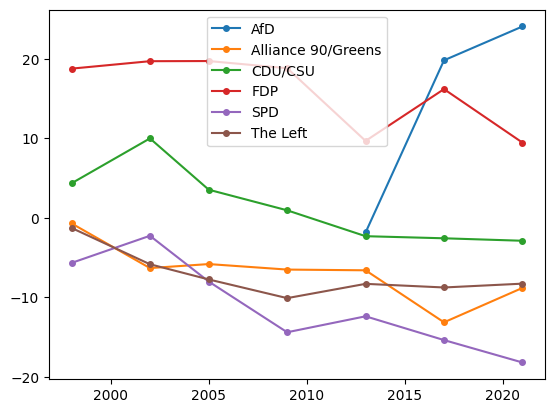

In [11]:
fig, ax = plt.subplots()
ax.margins(0.05) # Optional, just adds 5% padding to the autoscaling
for name, group in d2v_germany.groupby('party_name'):
    ax.plot(group.election, group.d2v_d1, marker='o',  ms=4, label=name)
ax.legend()

plt.show()

In [12]:
df_d2v.to_csv('data/py_outputs/r&c_gen.csv', index=False)

## Doc2Vec scaling - relevant topics
 

In [13]:
set(manifesto_d2v['topic'])

{'Agriculture - Protectionism',
 'Economics',
 'Education',
 'Environment - Growth',
 'European Integration',
 'Fabrics of Society',
 'Immigration',
 'International Relations',
 'Labour and Social Welfare',
 'Military',
 'Other',
 'Political System'}

In [14]:
# Create an empty list to store the country-topic level dataframes
country_topic_dfs = []

# Get the unique list of countries from your data
unique_countries = manifesto_d2v['countryname'].unique()

# Loop through each country
for country in unique_countries:
    print(f"Processing country: {country}")
    
    # Filter the dataset for the current country
    country_data = manifesto_d2v[manifesto_d2v['countryname'] == country]
    country_data = country_data[country_data['topic'].isin(['Environment - Growth', 'Political System', 'Economics',
                                                            'European Integration','Labour and Social Welfare',
                                                            'Immigration'])]
    # Get the unique list of topics within this country
    unique_topics = country_data['topic'].unique()
    
    # Loop through each topic in the country
    for topic in unique_topics:
        print(f"Processing topic: {topic}")

        # Filter the dataset for the current country and topic
        country_topic_data = country_data[country_data['topic'] == topic]

        # Build the corpus iterator for this country's topic-specific data
        outputs_stream = phraseIterator(country_topic_data, 'text_cleaned')
        bigram = Phraser(Phrases(outputs_stream, min_count=1, threshold=5))
        trigram = Phrases(bigram[outputs_stream], min_count=1, threshold=5)

        # Create the Doc2Vec model and build vocabulary
        model = Doc2Vec(vector_size=500, window=6, min_count=1, workers=16, epochs=20, seed=seed_val)
        model.build_vocab(corpusIterator(country_topic_data, bigram=bigram, trigram=trigram, text='text_cleaned', labels='party_election'))

        # Train the model
        model.train(corpusIterator(country_topic_data, bigram=bigram, trigram=trigram, text='text_cleaned', labels='party_election'),
                    total_examples=model.corpus_count, epochs=20)

        # Generate embeddings and apply dimensionality reduction
        embed_dict = d2v_reduct(model)
        df_d2v = pd.DataFrame.from_dict(embed_dict).transpose()
        df_d2v.index.name = 'party_election'
        df_d2v.reset_index(inplace=True)
        pca = PCA(n_components=2, random_state=seed_val)
        df_d2v[['d2v_d1', 'd2v_d2']] = pca.fit_transform(df_d2v.iloc[:, 1:])
        df_d2v = df_d2v[['party_election', 'd2v_d1', 'd2v_d2']]

        # Split the 'party_election' label into separate columns
        df_d2v[['party', 'election']] = df_d2v['party_election'].str.split('_', expand=True)
        df_d2v.loc[:, 'election'] = df_d2v['election'].astype(int)
        df_d2v['country'] = country  # Add country column
        df_d2v['topic'] = topic  # Add topic column

        # Append the country-topic-level dataframe to the list
        country_topic_dfs.append(df_d2v)

# Merge all country-topic-level datasets into a single dataframe
final_df_d2v = pd.concat(country_topic_dfs, ignore_index=True)

# Save the final dataframe to a CSV file
final_df_d2v.to_csv('data/py_outputs/r&c_party_election_topic.csv', index=False)

# Print a summary
print(final_df_d2v.info())


Processing country: Sweden
Processing topic: Economics
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Processing topic: Political System
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Processing topic: Labour and Social Welfare
Starting new epoch
Starting new epoch
Starting new epoch
Starting ne

## Doc2Vec scaling - Environment Protection
 

In [15]:
manifesto_ep = manifesto_d2v[manifesto_d2v.cmp_code.isin(['501'])].reset_index(drop=True)


In [16]:
manifesto_ep.head()

,text,text_en,cmp_code,eu_code,pos,manifesto_id,party,date,language,source,...,abbrev,name,edate,parfam,sentiment,topic,election,text_cleaned,party_election,country_party_election
0,och ett långsiktigt miljöansvar.,and long-term environmental responsibility.,501,NaN,5,11110_200609,11110,200609,swedish,MARPOR,...,MP,Miljöpartiet de Gröna,17/09/2006,10,left,Environment - Growth,2006,långsiktigt miljöansvar,11110_2006,Sweden_11110_2006
1,Vår politik kombinerar en grön omställning,Our policies combine a green transition,501,NaN,6,11110_200609,11110,200609,swedish,MARPOR,...,MP,Miljöpartiet de Gröna,17/09/2006,10,left,Environment - Growth,2006,politik kombinerar grön omställning,11110_2006,Sweden_11110_2006
2,"solidaritet med djur, natur och det ekologiska...","with animals, nature and the ecological system...",501,NaN,13,11110_200609,11110,200609,swedish,MARPOR,...,MP,Miljöpartiet de Gröna,17/09/2006,10,left,Environment - Growth,2006,solidaritet djur natur ekologiska systemet,11110_2006,Sweden_11110_2006
3,Vi vill att Sveriges beroende av olja och andr...,We want to break Sweden's dependence on oil an...,501,NaN,19,11110_200609,11110,200609,swedish,MARPOR,...,MP,Miljöpartiet de Gröna,17/09/2006,10,left,Environment - Growth,2006,vill sveriges beroende olja andra fossila brän...,11110_2006,Sweden_11110_2006
4,och hus byggas energisnålt.,and houses are built in an energy-efficient way.,501,NaN,22,11110_200609,11110,200609,swedish,MARPOR,...,MP,Miljöpartiet de Gröna,17/09/2006,10,left,Environment - Growth,2006,hus byggas energisnålt,11110_2006,Sweden_11110_2006


In [17]:
# Create an empty list to store the country-level dataframes
country_dfs = []

# Get the unique list of countries from your data
unique_countries = manifesto_ep['countryname'].unique()

# Loop through each country and process separately
for country in unique_countries:
    print(f"Processing country: {country}")
    
    # Filter the dataset for the current country
    country_data = manifesto_ep[manifesto_ep['countryname'] == country]
    
    # Build the corpus iterator for this country's data
    outputs_stream = phraseIterator(country_data, 'text_cleaned')
    bigram = Phraser(Phrases(outputs_stream, min_count=1, threshold=5))
    trigram = Phrases(bigram[outputs_stream], min_count=1, threshold=5)
    
    # Create the Doc2Vec model and build vocabulary
    model = Doc2Vec(vector_size=500, window=6, min_count=1, workers=16, epochs=20, seed=seed_val)
    model.build_vocab(corpusIterator(country_data, bigram=bigram, trigram=trigram, text='text_cleaned', labels='party_election'))
    
    # Train the model
    model.train(corpusIterator(country_data, bigram=bigram, trigram=trigram, text='text_cleaned', labels='party_election'),
                total_examples=model.corpus_count, epochs=20)
    
    # Generate embeddings and apply dimensionality reduction
    embed_dict = d2v_reduct(model)
    df_d2v = pd.DataFrame.from_dict(embed_dict).transpose()
    df_d2v.index.name = 'party_election'
    df_d2v.reset_index(inplace=True)
    pca = PCA(n_components=2, random_state=seed_val)
    df_d2v[['d2v_d1', 'd2v_d2']] = pca.fit_transform(df_d2v.iloc[:, 1:])
    df_d2v = df_d2v[['party_election', 'd2v_d1', 'd2v_d2']]
    
    # Split the 'party_election' label into separate columns
    df_d2v[['party', 'election']] = df_d2v['party_election'].str.split('_', expand=True)
    df_d2v.loc[:, 'election'] = df_d2v['election'].astype(int)
    df_d2v['country'] = country  # Add country column for merging later
    
    # Append the country-level dataframe to the list
    country_dfs.append(df_d2v)

# Merge all country-level datasets into a single dataframe
final_df_d2v = pd.concat(country_dfs, ignore_index=True)

# Save the final dataframe to a CSV file
final_df_d2v.to_csv('data/py_outputs/r&c_ep_party_election.csv', index=False)

# Print a summary
print(final_df_d2v.info())


Processing country: Sweden
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Processing country: Norway
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Processing country: Denmark
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starti

## Doc2Vec scaling - Welfare Expansion/Retrenchment
 

In [18]:
manifesto_welfare = manifesto_d2v[manifesto_d2v.cmp_code.isin(['504', '505'])].reset_index(drop=True)


In [19]:
manifesto_welfare.head()

,text,text_en,cmp_code,eu_code,pos,manifesto_id,party,date,language,source,...,abbrev,name,edate,parfam,sentiment,topic,election,text_cleaned,party_election,country_party_election
0,nya livschanser,new life chances,504,NaN,4,11110_200609,11110,200609,swedish,MARPOR,...,MP,Miljöpartiet de Gröna,17/09/2006,10,left,Labour and Social Welfare,2006,nya livschanser,11110_2006,Sweden_11110_2006
1,Det finns behov av och utrymme för fler anstäl...,There is a need and room for more employees in...,504,NaN,31,11110_200609,11110,200609,swedish,MARPOR,...,MP,Miljöpartiet de Gröna,17/09/2006,10,left,Labour and Social Welfare,2006,finns behov utrymme fler anställda offentligt ...,11110_2006,Sweden_11110_2006
2,Vi vill överföra pengar från arbetsmarknadsåtg...,We want to transfer money from labor market me...,504,NaN,32,11110_200609,11110,200609,swedish,MARPOR,...,MP,Miljöpartiet de Gröna,17/09/2006,10,left,Labour and Social Welfare,2006,vill överföra pengar arbetsmarknadsåtgärder an...,11110_2006,Sweden_11110_2006
3,"sjukvården,","healthcare,",504,NaN,35,11110_200609,11110,200609,swedish,MARPOR,...,MP,Miljöpartiet de Gröna,17/09/2006,10,left,Labour and Social Welfare,2006,sjukvården,11110_2006,Sweden_11110_2006
4,äldreomsorgen,elderly care,504,NaN,36,11110_200609,11110,200609,swedish,MARPOR,...,MP,Miljöpartiet de Gröna,17/09/2006,10,left,Labour and Social Welfare,2006,äldreomsorgen,11110_2006,Sweden_11110_2006


In [20]:
# Create an empty list to store the country-level dataframes
country_dfs = []

# Get the unique list of countries from your data
unique_countries = manifesto_welfare['countryname'].unique()

# Loop through each country and process separately
for country in unique_countries:
    print(f"Processing country: {country}")
    
    # Filter the dataset for the current country
    country_data = manifesto_welfare[manifesto_welfare['countryname'] == country]
    
    # Build the corpus iterator for this country's data
    outputs_stream = phraseIterator(country_data, 'text_cleaned')
    bigram = Phraser(Phrases(outputs_stream, min_count=1, threshold=5))
    trigram = Phrases(bigram[outputs_stream], min_count=1, threshold=5)
    
    # Create the Doc2Vec model and build vocabulary
    model = Doc2Vec(vector_size=500, window=6, min_count=1, workers=16, epochs=20, seed=seed_val)
    model.build_vocab(corpusIterator(country_data, bigram=bigram, trigram=trigram, text='text_cleaned', labels='party_election'))
    
    # Train the model
    model.train(corpusIterator(country_data, bigram=bigram, trigram=trigram, text='text_cleaned', labels='party_election'),
                total_examples=model.corpus_count, epochs=20)
    
    # Generate embeddings and apply dimensionality reduction
    embed_dict = d2v_reduct(model)
    df_d2v = pd.DataFrame.from_dict(embed_dict).transpose()
    df_d2v.index.name = 'party_election'
    df_d2v.reset_index(inplace=True)
    pca = PCA(n_components=2, random_state=seed_val)
    df_d2v[['d2v_d1', 'd2v_d2']] = pca.fit_transform(df_d2v.iloc[:, 1:])
    df_d2v = df_d2v[['party_election', 'd2v_d1', 'd2v_d2']]
    
    # Split the 'party_election' label into separate columns
    df_d2v[['party', 'election']] = df_d2v['party_election'].str.split('_', expand=True)
    df_d2v.loc[:, 'election'] = df_d2v['election'].astype(int)
    df_d2v['country'] = country  # Add country column for merging later
    
    # Append the country-level dataframe to the list
    country_dfs.append(df_d2v)

# Merge all country-level datasets into a single dataframe
final_df_d2v = pd.concat(country_dfs, ignore_index=True)

# Save the final dataframe to a CSV file
final_df_d2v.to_csv('data/py_outputs/r&c_welfare_party_election.csv', index=False)

# Print a summary
print(final_df_d2v.info())


Processing country: Sweden
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Processing country: Norway
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Processing country: Denmark
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starti

## Doc2Vec scaling - Twitter dataset

In [21]:
tw_processed = pd.read_csv('data/py_outputs/tw_processed.csv', encoding='utf-8')
tw_processed.loc[:,'countryname'] = 'US'
tw_processed.loc[:,'text_cleaned'] = clean_text_loop(tw_processed, 'countryname')


Cleaning the 0th sentence
Cleaning the 10000th sentence
Cleaning the 20000th sentence
Cleaning the 30000th sentence


In [22]:
outputs_stream = phraseIterator(tw_processed, 'text_cleaned')
bigram = Phraser(Phrases(outputs_stream, min_count=1, threshold=5))
trigram = Phrases(bigram[outputs_stream], min_count=1, threshold=5)

# Create the Doc2Vec model and build vocabulary
model = Doc2Vec(vector_size=500, window=6, min_count=1, workers=16, epochs=20, seed=seed_val)
model.build_vocab(corpusIterator(tw_processed, bigram=bigram, trigram=trigram, text='text_cleaned', labels='topic_lr'))

# Train the model
model.train(corpusIterator(tw_processed, bigram=bigram, trigram=trigram, text='text_cleaned', labels='topic_lr'),
            total_examples=model.corpus_count, epochs=20)

# Generate embeddings and apply dimensionality reduction
embed_dict = d2v_reduct(model)
df_d2v = pd.DataFrame.from_dict(embed_dict).transpose()
df_d2v.index.name = 'topic_lr'
df_d2v.reset_index(inplace=True)
pca = PCA(n_components=2, random_state=seed_val)
df_d2v[['d2v_d1', 'd2v_d2']] = pca.fit_transform(df_d2v.iloc[:, 1:])
df_d2v = df_d2v[['topic_lr', 'd2v_d1', 'd2v_d2']]

# Split the 'party_election' label into separate columns
df_d2v[['topic', 'lr']] = df_d2v['topic_lr'].str.split('_', expand=True)

Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch
Starting new epoch


In [23]:
df_d2v.to_csv('data/py_outputs/r&c_tw.csv', index=False)